22-Mar-26(17:22:21)[IPYKERNEL_LAUNCHER]INFO      Iniciando Descenso de Gradiente (Max 20 iteraciones)...
22-Mar-26(17:22:21)[IPYKERNEL_LAUNCHER]INFO      Capturing PSD [[1/8]]
22-Mar-26(17:22:22)[IPYKERNEL_LAUNCHER]DEBUG     Acquiring CF: 98.0 MHz
22-Mar-26(17:22:22)[IPYKERNEL_LAUNCHER]INFO      Capturing PSD [[2/8]]
22-Mar-26(17:22:22)[IPYKERNEL_LAUNCHER]DEBUG     Acquiring CF: 98.0 MHz
22-Mar-26(17:22:24)[IPYKERNEL_LAUNCHER]INFO      Capturing PSD [[3/8]]
22-Mar-26(17:22:24)[IPYKERNEL_LAUNCHER]DEBUG     Acquiring CF: 98.0 MHz
22-Mar-26(17:22:26)[IPYKERNEL_LAUNCHER]INFO      Capturing PSD [[4/8]]
22-Mar-26(17:22:26)[IPYKERNEL_LAUNCHER]DEBUG     Acquiring CF: 98.0 MHz
22-Mar-26(17:22:27)[IPYKERNEL_LAUNCHER]INFO      Capturing PSD [[5/8]]
22-Mar-26(17:22:27)[IPYKERNEL_LAUNCHER]DEBUG     Acquiring CF: 98.0 MHz
22-Mar-26(17:22:28)[IPYKERNEL_LAUNCHER]INFO      Capturing PSD [[6/8]]
22-Mar-26(17:22:28)[IPYKERNEL_LAUNCHER]DEBUG     Acquiring CF: 98.0 MHz
22-Mar-26(17:22:29)[IPYKERNEL_LAUNCHE

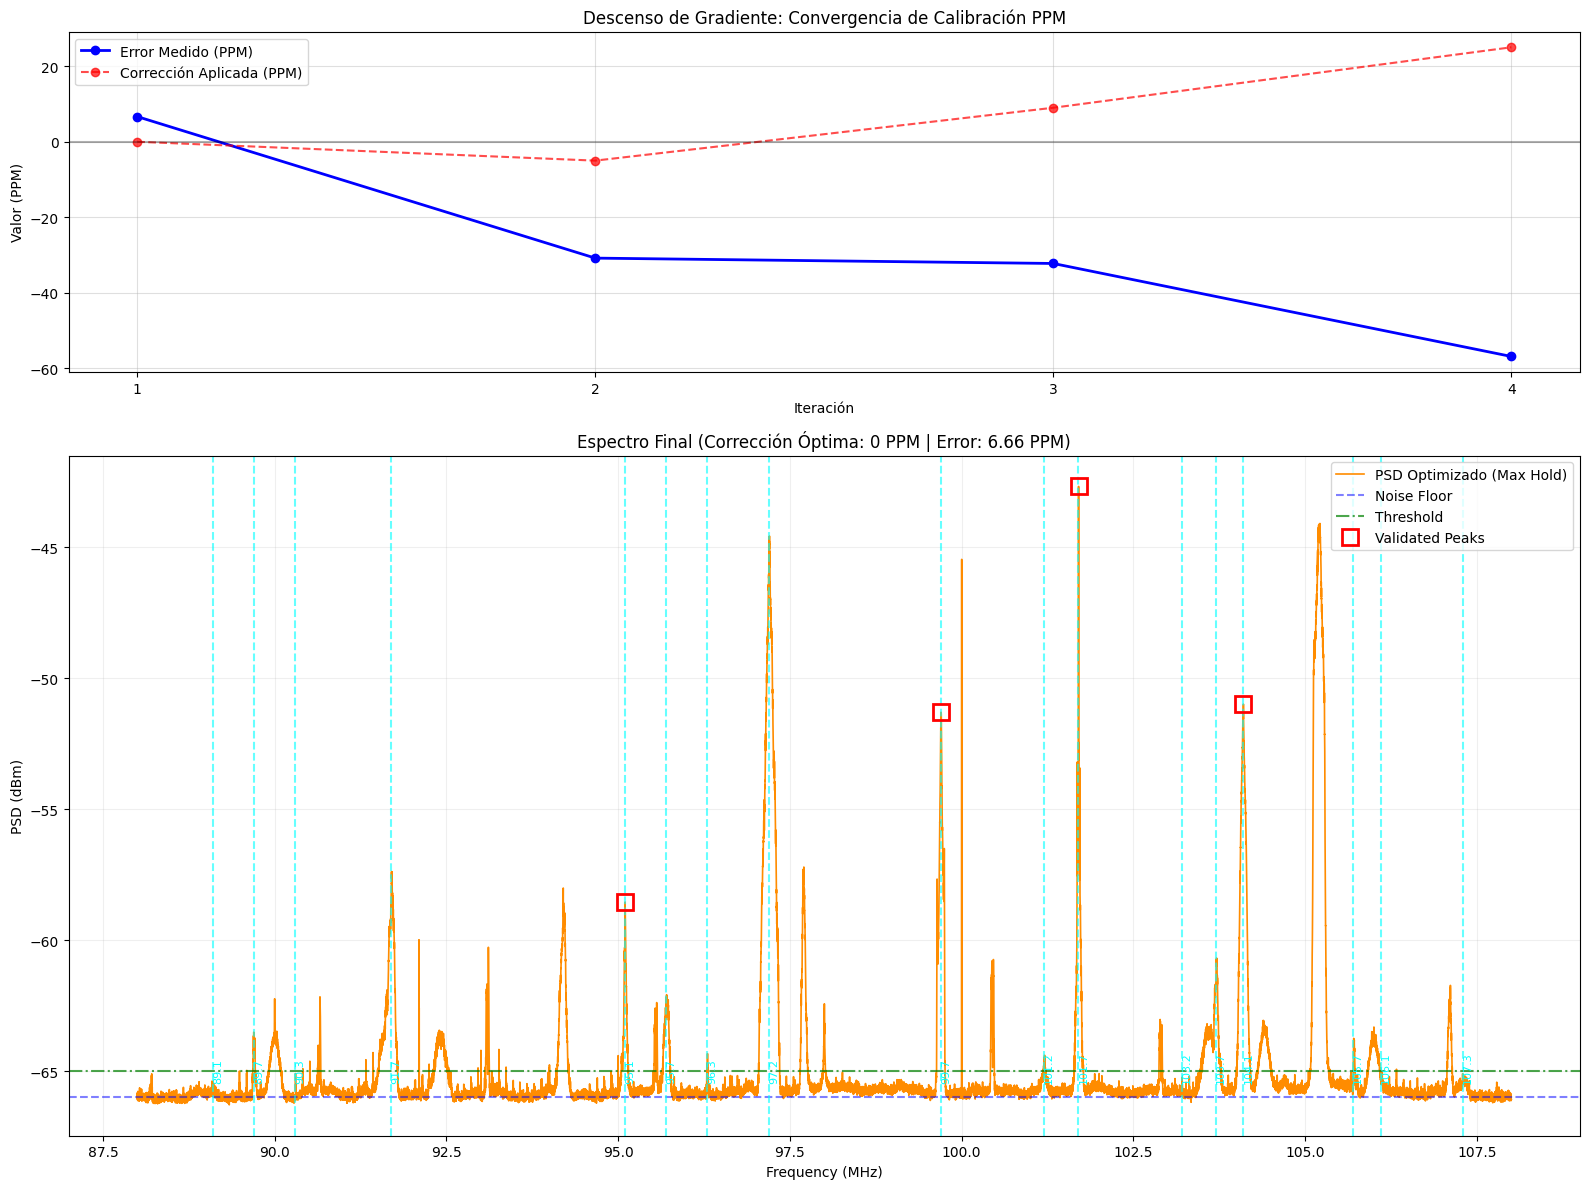

22-Mar-26(17:23:02)[IPYKERNEL_LAUNCHER]INFO      Ejecución finalizada con código: 0


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
import time

# Configuración del entorno y path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import nest_asyncio
nest_asyncio.apply()

import cfg
log = cfg.set_logger()

# Importar dependencias del proyecto y de la clase base
from utils import ServerRealtimeConfig
from FM_sync import FmCalibrator, CalibratorConfig, AnalysisResult

# ---------------------------------------------------------
# CONFIGURACIÓN Y RESULTADOS DEL GRADIENTE
# ---------------------------------------------------------
@dataclass
class GradientConfig(CalibratorConfig):
    max_iterations: int = 20
    patience: int = 3
    learning_rate: float = 0.8

@dataclass
class OptimizationResult:
    best_correction: int
    best_error: float
    history: list
    final_analysis: AnalysisResult

# ---------------------------------------------------------
# CLASE OPTIMIZADORA (Hereda de FM_sync)
# ---------------------------------------------------------
class FmGradientOptimizer(FmCalibrator):
    def __init__(self, config: GradientConfig):
        super().__init__(config)
        self.grad_cfg = config

    async def optimize(self, base_sdr_cfg: ServerRealtimeConfig, legal_freqs: list) -> OptimizationResult:
        log.info(f"Iniciando Descenso de Gradiente (Max {self.grad_cfg.max_iterations} iteraciones)...")
        history = []
        current_correction = 0.0
        best_error = float('inf')
        best_correction = 0
        patience_counter = 0
        best_analysis = None
        prev_error = None

        for i in range(self.grad_cfg.max_iterations):
            # Aseguramos que la corrección sea un entero (SDR lo requiere así)
            applied_correction = int(round(current_correction))
            
            # Aplicar corrección al SDR
            cfg_dict = asdict(base_sdr_cfg)
            cfg_dict['ppm_error'] = applied_correction
            
            # Adquirir y procesar
            rf = await self.acquire_psd(ServerRealtimeConfig(**cfg_dict))
            res = self.process_payload(rf, legal_freqs)
            
            error = res.ppm
            history.append({
                'iteration': i + 1, 'correction': applied_correction,
                'error': error, 'abs_error': abs(error)
            })

            log.info(f"Iter [{i+1:02d}] -> Corrección SDR: {applied_correction} PPM | Error: {error:+.2f} PPM")

            # 1. EARLY STOPPING PERFECTO: Si estamos a menos de 1 PPM, ganamos.
            if abs(error) < 1.0:
                log.info("¡Convergencia ideal! Error menor a 1 PPM.")
                best_error = abs(error)
                best_correction = applied_correction
                best_analysis = res
                break

            # 2. EVALUAR PACIENCIA
            if abs(error) < best_error:
                best_error = abs(error)
                best_correction = applied_correction
                best_analysis = res
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= self.grad_cfg.patience:
                log.info(f"Sin mejora en {self.grad_cfg.patience} intentos. Abortando búsqueda.")
                break

            # 3. LEARNING RATE ADAPTATIVO (Decay on Overshoot)
            if prev_error is not None and (error * prev_error < 0):
                self.grad_cfg.learning_rate *= 0.6  # Reducir el paso si saltamos sobre el 0
                log.debug(f"Overshoot detectado. Learning Rate ajustado a {self.grad_cfg.learning_rate:.2f}")

            # 4. ACTUALIZAR GRADIENTE
            current_correction -= self.grad_cfg.learning_rate * error
            prev_error = error

        log.info(f"🏆 Gradiente finalizado. Mejor Corrección: {best_correction} (Error Residual: {best_error:.2f} PPM)")
        return OptimizationResult(best_correction, best_error, history, best_analysis)

# ---------------------------------------------------------
# FLUJO PRINCIPAL Y DIBUJO
# ---------------------------------------------------------
async def main():
    db_path = cfg.PROJECT_ROOT / "db" / "ANE_db_reference.csv"
    lat, lng, coverage_m = 5.0310736, -75.5894066, 15000
    
    sdr_cfg = ServerRealtimeConfig(
        method_psd="welch", center_freq_hz=int(98e6), sample_rate_hz=int(20e6),
        rbw_hz=int(1e3), window="hamming", overlap=float(0.5), lna_gain=int(8),
        vga_gain=int(8), antenna_amp=bool(False), antenna_port=int(1), ppm_error=0,
    )
    
    optimizer = FmGradientOptimizer(GradientConfig())
    legal_freqs = optimizer.get_legal_freqs(db_path, lat, lng, coverage_m)
    
    opt_res = await optimizer.optimize(sdr_cfg, legal_freqs)
    hist_df = pd.DataFrame(opt_res.history)

    # Plotting
    fig, (ax_grad, ax_spec) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 2]})
    
    ax_grad.plot(hist_df['iteration'], hist_df['error'], 'bo-', label='Error Medido (PPM)', linewidth=2)
    ax_grad.plot(hist_df['iteration'], hist_df['correction'], 'ro--', label='Corrección Aplicada (PPM)', alpha=0.7)
    ax_grad.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax_grad.set_title("Descenso de Gradiente: Convergencia de Calibración PPM")
    ax_grad.set_xlabel("Iteración")
    ax_grad.set_ylabel("Valor (PPM)")
    ax_grad.set_xticks(hist_df['iteration'])
    ax_grad.legend()
    ax_grad.grid(True, alpha=0.4)

    res = opt_res.final_analysis
    ax_spec.plot(res.freqs, res.psd, color='darkorange', linewidth=1.2, label='PSD Optimizado (Max Hold)')
    ax_spec.axhline(res.noise_floor, color='blue', linestyle='--', alpha=0.5, label='Noise Floor')
    ax_spec.axhline(res.threshold, color='green', linestyle='-.', alpha=0.7, label='Threshold')
    
    for f_legal in [f for f in legal_freqs if res.freqs.min() <= f <= res.freqs.max()]:
        ax_spec.axvline(f_legal, color='cyan', linestyle='--', alpha=0.6)
        ax_spec.text(f_legal, ax_spec.get_ylim()[0] + 2, f"{f_legal}", color='cyan', rotation=90, fontsize=8, va='bottom')

    if res.validated_candidates:
        val_idx = [item[0] for item in res.validated_candidates]
        ax_spec.plot(res.freqs[val_idx], res.psd[val_idx], "rs", markersize=12, markerfacecolor='none', markeredgewidth=2, label='Validated Peaks')

    ax_spec.set_xlabel("Frequency (MHz)")
    ax_spec.set_ylabel("PSD (dBm)")
    ax_spec.set_title(f"Espectro Final (Corrección Óptima: {opt_res.best_correction} PPM | Error: {opt_res.best_error:.2f} PPM)")
    ax_spec.legend(loc='upper right')
    ax_spec.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

    return 0

if __name__ == "__main__":
    rc = cfg.run_and_capture(main)
    log.info(f"Ejecución finalizada con código: {rc}")